# Korea, US, and Crypto Multi-Market Decomposition

This notebook combines Korean equities, US ETFs, and crypto pairs. The purpose is to show how De-Time features can support cross-market timing and regime research. Crypto is traded 24/7, while equity markets have exchange calendars; production research must treat calendars separately.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
tickers = ["005930.KS", "000660.KS", "035420.KS", "SPY", "QQQ", "BTC-USD", "ETH-USD"]
prices = fetch_yahoo_prices(tickers, start="2018-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache", min_observations=500)
data_audit_report(prices)

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,005930.KS,2018-01-01,2026-05-22,3064,0.0,31213.433594,2.995000e+05
1,000660.KS,2018-01-01,2026-05-22,3064,0.0,53071.500000,1.976000e+06
2,035420.KS,2018-01-01,2026-05-22,3064,0.0,103009.718750,4.418342e+05
3,SPY,2018-01-01,2026-05-22,3064,0.0,204.944901,7.481700e+02
4,QQQ,2018-01-01,2026-05-22,3064,0.0,137.163361,7.204600e+02
5,BTC-USD,2018-01-01,2026-05-22,3064,0.0,3236.761719,1.247525e+05
6,ETH-USD,2018-01-01,2026-05-22,3064,0.0,84.308296,4.831349e+03


In [3]:
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
regime = residual_stress_filter(prices, features, max_abs_residual_z=3.0, require_positive_trend=False)
regime.tail()

Ticker,005930.KS,000660.KS,035420.KS,SPY,QQQ,BTC-USD,ETH-USD
Date,,,,,,,
2026-05-18,True,True,True,True,True,True,True
2026-05-19,True,True,True,True,True,True,True
2026-05-20,True,True,True,True,True,True,True
2026-05-21,True,True,True,True,True,True,True
2026-05-22,True,True,True,True,True,True,True


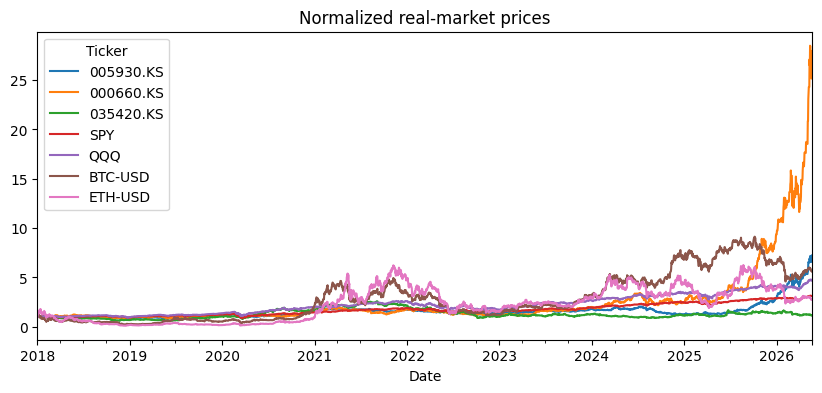

In [4]:
normalized = prices / prices.iloc[0]
normalized.plot(figsize=(10, 4), title="Normalized real-market prices")
plt.show()

Research extensions: cross-market lead-lag, shared semiconductor cycle, crypto risk-on/risk-off filter, and FX-adjusted Korea/US relative value.